In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

In [8]:
df = pd.read_csv("Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [9]:
print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [10]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [11]:
df.dropna(inplace=True)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
print("\nDataset Shape :", df.shape)


Dataset Shape : (324, 6)


In [14]:
le = LabelEncoder()

df["Education Level"] = le.fit_transform(
    df["Education Level"]
)

In [15]:
X = df[["Years of Experience", "Education Level"]]
y = df["Salary"]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 50)
print("MODEL VALIDATION")
print("=" * 50)

print("R2 Score :", round(r2, 4))


MODEL VALIDATION
R2 Score : 0.8617


In [20]:
print("\nIntercept")
print(round(model.intercept_, 2))

print("\nCoefficients")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", round(coef, 2))


Intercept
32451.64

Coefficients
Years of Experience : 5965.31
Education Level : 14418.37


In [21]:
import pandas as pd

experience = float(input("\nEnter Years of Experience : "))

education = input(
    "\nEnter Education Level (Bachelor/Master/PhD) : "
).strip().lower()

education_mapping = {
    "bachelor": 0,
    "master": 1,
    "phd": 2
}

if education not in education_mapping:
    print("Invalid Education Level")
else:

    education_encoded = education_mapping[education]

    user_data = pd.DataFrame(
        [[experience, education_encoded]],
        columns=[
            "Years of Experience",
            "Education Level"
        ]
    )

    salary = model.predict(user_data)

    print("\n" + "=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)

    print("Experience :", experience)
    print("Education  :", education.title())

    print(
        "\nPredicted Salary : ₹",
        round(salary[0], 2)
    )


Enter Years of Experience : 6

Enter Education Level (Bachelor/Master/PhD) : PhD

PREDICTION RESULT
Experience : 6.0
Education  : Phd

Predicted Salary : ₹ 97080.22


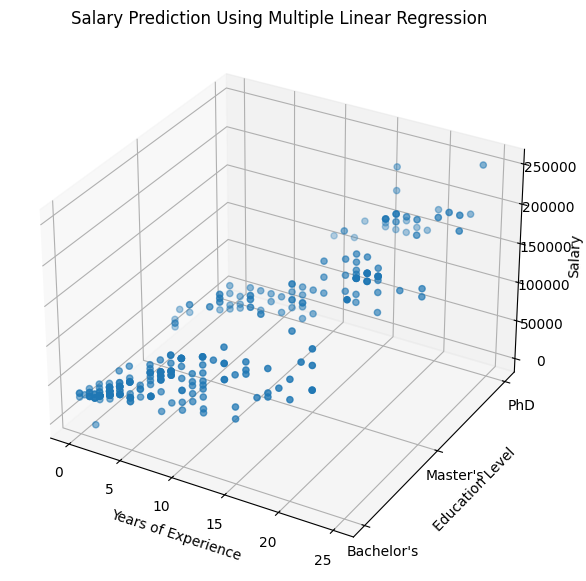

In [22]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    df["Years of Experience"],
    df["Education Level"],
    df["Salary"]
)

ax.set_xlabel("Years of Experience")
ax.set_ylabel("Education Level")
ax.set_zlabel("Salary")

education_values = sorted(
    df["Education Level"].unique()
)

education_names = le.inverse_transform(
    education_values
)

ax.set_yticks(education_values)
ax.set_yticklabels(education_names)

plt.title(
    "Salary Prediction Using Multiple Linear Regression"
)

plt.show()